Import all libraries

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

Defining the state in Pydantic Model

In [3]:
class BatsmanState(TypedDict):

    # input fields
    runs: int
    balls: int
    fours: int
    sixes: int

    # output fields
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str

Defining Nodes which is nothing but a python functions

In [17]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs'] / state['balls']) * 100
    return {'strike_rate': round(sr, 2)}

In [18]:
def calculate_bpb(state: BatsmanState):

    total_boundaries = state['fours'] + state['sixes']
    bpb = state['balls'] / total_boundaries if total_boundaries > 0 else 0
    return {'balls_per_boundary': round(bpb, 2)}

In [19]:
def calculate_boundary_percentage(state: BatsmanState):

    boundary_percentage = ((state['fours']*4 + state['sixes']*6) / state['runs']) * 100 if state['runs'] > 0 else 0
    return {'boundary_percentage': round(boundary_percentage, 2)}

In [20]:
def summary(state: BatsmanState):

    summary = f"""
    Strike Rate: {state['strike_rate']}\n
    Balls Per Boundary: {state['balls_per_boundary']}\n
    Boundary Percentage: {state['boundary_percentage']}\n
    """
    return {'summary': summary}

Graph Creation

In [21]:
graph = StateGraph(BatsmanState)

Adding nodes to the graphs and also edges the graph for the routing

In [22]:
graph.add_node("Calculate Strike Rate", calculate_sr)
graph.add_node("Calculate Balls Per Boundary", calculate_bpb)
graph.add_node("Calculate Boundary Percentage", calculate_boundary_percentage)
graph.add_node("Summary", summary)



graph.add_edge(START, "Calculate Strike Rate")
graph.add_edge(START, "Calculate Balls Per Boundary")  
graph.add_edge(START, "Calculate Boundary Percentage")

graph.add_edge("Calculate Strike Rate", "Summary")
graph.add_edge("Calculate Balls Per Boundary", "Summary")
graph.add_edge("Calculate Boundary Percentage", "Summary")

graph.add_edge("Summary", END)

Compiling and viewing the graph

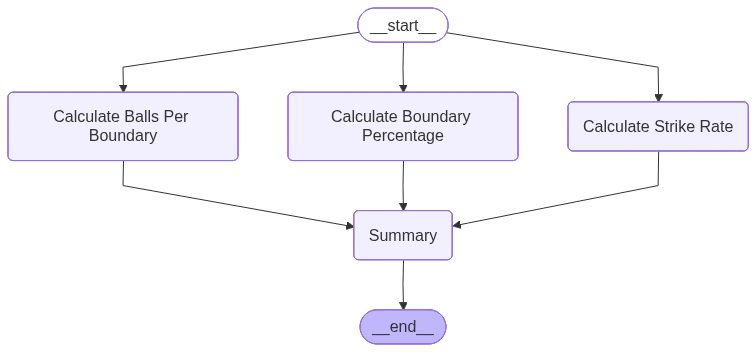

In [23]:
graph.compile()

In [24]:
workflow = graph.compile()

Graphs Execution

In [25]:
initial_state = {'runs': 150, 'balls': 120, 'fours': 10, 'sixes': 5}
workflow.invoke(initial_state)

{'runs': 150,
 'balls': 120,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 125.0,
 'balls_per_boundary': 8.0,
 'boundary_percentage': 46.67,
 'summary': '\n    Strike Rate: 125.0\n\n    Balls Per Boundary: 8.0\n\n    Boundary Percentage: 46.67\n\n    '}

Note: That in above all the nodes partial state is returned rather than a full state because if a full state is returned by all the nodes parellely then langgraph misinterprets that changes is made in the entire state by each node in parallel, so a partial state is being return for a clarity that which state is changed by which node and universally it is a better approach.